# 04 - Exploración de datos reales

Cuaderno para revisar capturas reales de la maqueta de tren antes de emplearlas en la fase de entrenamiento.

Convención de nomenclatura:

```text
datos/brutos/normal_run_001.csv
datos/brutos/normal_run_002.csv
datos/brutos/anomaly_run_001.csv
```

Actualmente no se emplea un registro externo. El tipo de captura se infiere a partir del nombre del archivo.


In [1]:
from pathlib import Path
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
def find_project_root():
    candidates = [
        Path.cwd().resolve(),
        Path.cwd().resolve().parent,
        Path.cwd().resolve().parent.parent,
        Path("/workspace/TFM"),
    ]
    for candidate in candidates:
        if (candidate / "datos" / "raw").exists() and (candidate / "inference_server").exists():
            return candidate
    raise FileNotFoundError("No se encontró el directorio raíz del proyecto con datos/brutos e inference_server")

PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "datos" / "raw"
print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"RAW_DIR={RAW_DIR}")


PROJECT_ROOT=/workspace/TFM
RAW_DIR=/workspace/TFM/datos/brutos


In [3]:
normal_files = sorted(RAW_DIR.glob("normal_run_*.csv"))
anomaly_files = sorted(RAW_DIR.glob("anomaly_run_*.csv"))
debug_files = sorted(p for p in RAW_DIR.glob("*.csv") if p not in normal_files and p not in anomaly_files)

print("Ejecuciones normales (Normal runs):")
for path in normal_files:
    print(" -", path.name)

print("\nEjecuciones con anomalías (Anomaly runs):")
for path in anomaly_files:
    print(" -", path.name)

print("\nOtros CSVs / Depuración:")
for path in debug_files:
    print(" -", path.name)


Normal runs:

Anomaly runs:

Other/debug CSVs:
 - real_movement_002.csv
 - real_normal_001.csv
 - wifi_test_001.csv


In [4]:
REQUIRED_COLUMNS = ["seq", "timestamp_ms", "acc_x_g", "acc_y_g", "acc_z_g"]


def read_capture(path):
    df = pd.read_csv(path)
    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en {path.name}: {missing}")
    return df


def analyze_capture(df, expected_hz=100.0):
    if len(df) == 0:
        return {
            "rows": 0,
            "resets": 0,
            "lost_packets": 0,
            "loss_ratio": np.nan,
            "duration_s": np.nan,
            "rate_hz": np.nan,
            "max_gap_ms": np.nan,
            "acceptable": False,
        }

    seq = df["seq"].to_numpy(dtype=np.int64)
    ts = df["timestamp_ms"].to_numpy(dtype=np.int64)
    seq_delta = np.diff(seq)
    ts_delta = np.diff(ts)

    resets = int((seq_delta < 0).sum())
    lost_packets = int(np.maximum(seq_delta - 1, 0).sum())
    expected_packets = int(seq[-1] - seq[0] + 1) if resets == 0 else None
    loss_ratio = lost_packets / expected_packets if expected_packets and expected_packets > 0 else np.nan

    duration_s = (ts[-1] - ts[0]) / 1000 if ts[-1] > ts[0] else np.nan
    rate_hz = len(df) / duration_s if duration_s and duration_s > 0 else np.nan
    max_gap_ms = int(ts_delta.max()) if len(ts_delta) else 0

    acceptable = (
        len(df) > 0
        and resets == 0
        and (np.isnan(loss_ratio) or loss_ratio <= 0.01)
        and (np.isnan(rate_hz) or abs(rate_hz - expected_hz) / expected_hz <= 0.05)
    )

    return {
        "rows": len(df),
        "seq_first": int(seq[0]),
        "seq_last": int(seq[-1]),
        "resets": resets,
        "lost_packets": lost_packets,
        "loss_ratio": loss_ratio,
        "duration_s": duration_s,
        "rate_hz": rate_hz,
        "max_gap_ms": max_gap_ms,
        "acceptable": acceptable,
    }


In [5]:
summary_rows = []
for label, files in [("normal", normal_files), ("anomaly", anomaly_files), ("debug", debug_files)]:
    for path in files:
        try:
            df = read_capture(path)
            stats = analyze_capture(df)
        except Exception as exc:
            stats = {"rows": 0, "acceptable": False, "error": str(exc)}
        summary_rows.append({"file": path.name, "label": label, **stats})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,file,label,rows,seq_first,seq_last,resets,lost_packets,loss_ratio,duration_s,rate_hz,max_gap_ms,acceptable
0,real_movement_002.csv,debug,360012,404912,764923,2,4,NaN,3600.13,99.999722,20,False
1,real_normal_001.csv,debug,360013,36964,396977,2,5,NaN,3600.13,100.000000,20,False
2,wifi_test_001.csv,debug,1031,391,2392,0,971,0.485015,20.01,51.524238,1040,False


## Selección de archivo para inspección visual

Por defecto, se emplea el primer archivo `normal_run_*.csv`. En caso de que aún no existan capturas con dicha nomenclatura, se seleccionará el archivo CSV de mayor tamaño disponible en el directorio `datos/brutos` para verificar el correcto funcionamiento del cuaderno.


In [6]:
def choose_default_file():
    if normal_files:
        return normal_files[0]
    all_csv = sorted(RAW_DIR.glob("*.csv"), key=lambda p: p.stat().st_size, reverse=True)
    if all_csv:
        return all_csv[0]
    raise FileNotFoundError("No se han encontrado archivos CSV en el directorio datos/brutos.")

SELECTED_FILE = choose_default_file()
print(f"SELECTED_FILE={SELECTED_FILE.name}")
df = read_capture(SELECTED_FILE)
display(df.head())
display(pd.DataFrame([analyze_capture(df)]))


SELECTED_FILE=real_movement_002.csv


,pc_timestamp_ns,sender_ip,seq,timestamp_ms,acc_x_g,acc_y_g,acc_z_g
0,1780510650538818470,192.168.1.188,404912,4052780,0.6435,0.0741,-0.1248
1,1780510650548152460,192.168.1.188,404913,4052790,1.4508,-0.1248,-0.1053
2,1780510650558037382,192.168.1.188,404914,4052800,1.0296,-0.1365,0.0585
3,1780510650568323037,192.168.1.188,404915,4052810,0.6474,0.0195,-0.0741
4,1780510650581314315,192.168.1.188,404916,4052820,0.9789,0.1287,-0.0702


,rows,seq_first,seq_last,resets,lost_packets,loss_ratio,duration_s,rate_hz,max_gap_ms,acceptable
0,360012,404912,764923,2,4,NaN,3600.13,99.999722,20,False


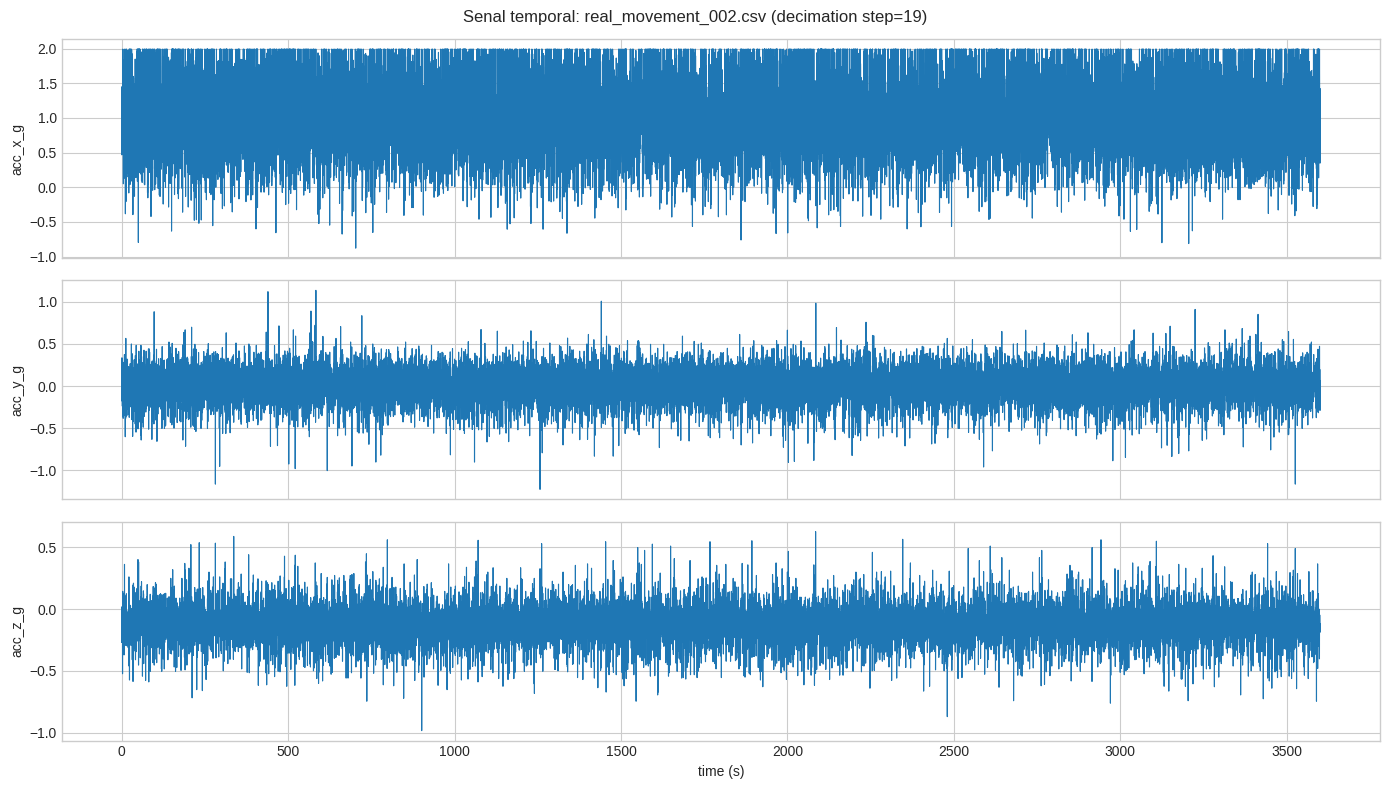

In [7]:
# Vista temporal completa; se aplica diezmado (decimation) si el archivo excede un número elevado de muestras para optimizar la visualización.
plot_df = df.copy()
if len(plot_df) > 20000:
    step = int(np.ceil(len(plot_df) / 20000))
    plot_df = plot_df.iloc[::step].copy()
else:
    step = 1

plot_df["time_s"] = (plot_df["timestamp_ms"] - plot_df["timestamp_ms"].iloc[0]) / 1000.0

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for ax, col in zip(axes, ["acc_x_g", "acc_y_g", "acc_z_g"]):
    ax.plot(plot_df["time_s"], plot_df[col], linewidth=0.8)
    ax.set_ylabel(col)
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"Señal temporal: {SELECTED_FILE.name} (decimation step={step})")
plt.tight_layout()
plt.show()


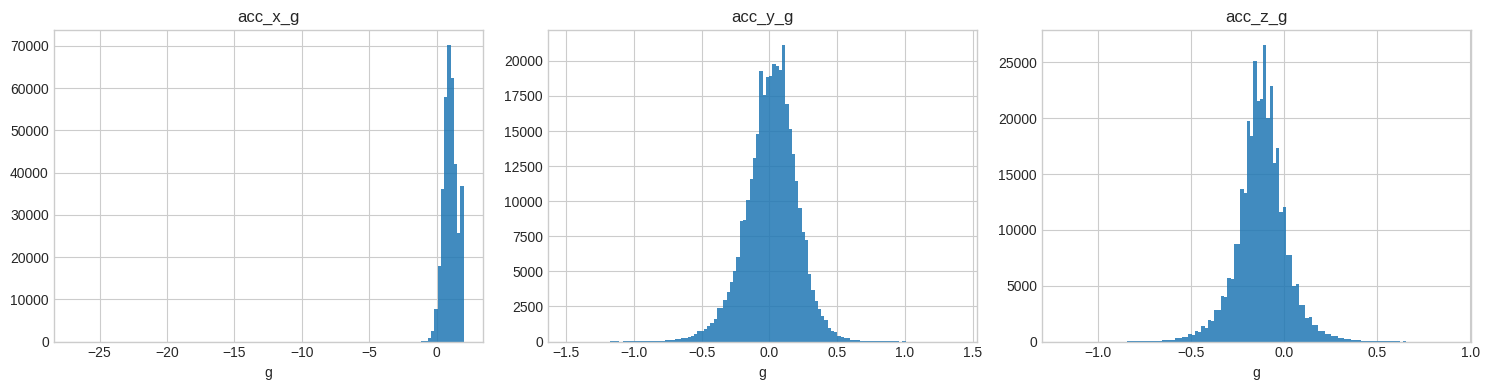

In [8]:
# Distribuciones estadísticas por eje de aceleración.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["acc_x_g", "acc_y_g", "acc_z_g"]):
    ax.hist(df[col], bins=120, alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel("g")
plt.tight_layout()
plt.show()


In [9]:
# Extracción de características por ventana: procedimiento útil para analizar la estabilidad de la señal y preparar el modelo de referencia (baseline) o el modelo VAE.
WINDOW_SIZE = 100
WINDOW_STEP = 50

values = df[["acc_x_g", "acc_y_g", "acc_z_g"]].to_numpy(dtype=np.float32)
starts = range(0, len(values) - WINDOW_SIZE + 1, WINDOW_STEP)
rows = []
for window_idx, start in enumerate(starts):
    w = values[start:start + WINDOW_SIZE]
    centered = w - w.mean(axis=0, keepdims=True)
    magnitude = np.linalg.norm(w, axis=1)
    rows.append({
        "window_idx": window_idx,
        "start_s": (df["timestamp_ms"].iloc[start] - df["timestamp_ms"].iloc[0]) / 1000.0,
        "vibration_rms": float(np.sqrt(np.mean(centered ** 2))),
        "mag_std": float(np.std(magnitude)),
        "x_std": float(np.std(w[:, 0])),
        "y_std": float(np.std(w[:, 1])),
        "z_std": float(np.std(w[:, 2])),
    })
features_df = pd.DataFrame(rows)
display(features_df.describe())


,window_idx,start_s,vibration_rms,mag_std,x_std,y_std,z_std
count,7199.000000,7199.000000,7199.000000,7199.000000,7199.000000,7199.000000,7199.000000
mean,3599.000000,1799.509501,0.325318,0.480575,0.513789,0.187930,0.131569
std,2078.316627,1039.163105,0.039028,0.059085,0.069388,0.020043,0.015565
min,0.000000,0.000000,0.225687,0.318878,0.334037,0.127884,0.087173
25%,1799.500000,899.760000,0.302113,0.447162,0.472340,0.173925,0.120890
50%,3599.000000,1799.510000,0.323054,0.477591,0.509306,0.186794,0.130356
75%,5398.500000,2699.260000,0.347169,0.512703,0.553634,0.200156,0.140968
max,7198.000000,3599.020000,1.634268,2.616183,2.822639,0.310405,0.234520


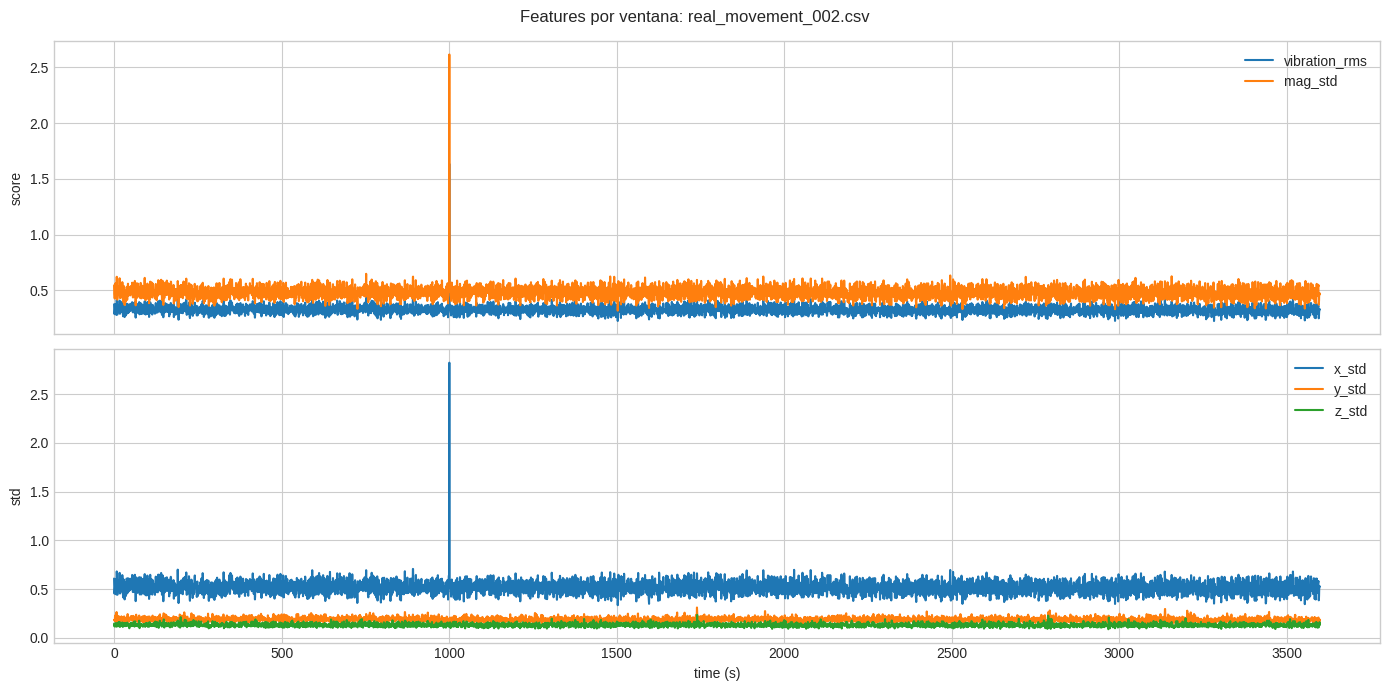

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(features_df["start_s"], features_df["vibration_rms"], label="vibration_rms")
axes[0].plot(features_df["start_s"], features_df["mag_std"], label="mag_std")
axes[0].set_ylabel("score")
axes[0].legend()

axes[1].plot(features_df["start_s"], features_df["x_std"], label="x_std")
axes[1].plot(features_df["start_s"], features_df["y_std"], label="y_std")
axes[1].plot(features_df["start_s"], features_df["z_std"], label="z_std")
axes[1].set_ylabel("std")
axes[1].set_xlabel("time (s)")
axes[1].legend()
fig.suptitle(f"Características extraídas por ventana: {SELECTED_FILE.name}")
plt.tight_layout()
plt.show()


## Criterios prácticos de inclusión

Un archivo `normal_run_*.csv` se considera apto para la fase de entrenamiento si cumple con las siguientes condiciones:

- `acceptable == True`.
- `resets == 0`.
- Tasa de pérdida (`loss_ratio`) cercana a 0.
- Frecuencia de muestreo (`rate_hz`) próxima a 100 Hz.
- Ausencia de segmentos anómalos visualmente detectables ocasionados por cortes mecánicos o deficiencias en la alimentación eléctrica.

Las capturas con nomenclaturas `debug_*`, `real_stoped_*` o pruebas consideradas fallidas no se utilizarán para el entrenamiento del modelo, a menos que se requiera realizar un análisis exhaustivo de la estabilidad del hardware.
